## Submit Portfolio of Trades to QRT

In [79]:
import os
import logging
import numpy as np
import pandas as pd
from glob import glob
from typing import Literal
import matplotlib.pyplot as plt
from local_data.LSEG_data import *
from clients.qsec_client.sample_code import *


GROUP_ID = 'ICL05'
USER = 'q8576'
KEY_PATH = os.path.expanduser('~/.ssh/icl05_id_rsa')
TARGETS_PATH = 'target_files/'

logging.basicConfig(filename='logs/send_portfolio.log', level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

def send_new_portfolio(targets: pd.DataFrame, region: Literal['AMER', 'EMEA']):
    """Update the actual team portfolio at the current market prices.
    targets = pd.DataFrame({'internal_code': 'AAPL.OQ', 'currency': 'USD', 'target_notional': 100})
    """
    try:
        target_path = prepare_targets_file(targets, GROUP_ID, region, TARGETS_PATH)
        display(pd.read_csv(target_path))
        formating_issues = validate_targets_file(target_path)
        if formating_issues == []:
            upload_targets_file(
                targets_csv_path=target_path, 
                region=region, 
                sftp_username=USER, 
                private_key_path=KEY_PATH,
                sftp_host='sftp.qrt.cloud'
            )
            logging.info(f"Portfolio successfully uploaded: {target_path}")
        else:
            logging.error(f"Validation failed, portfolio not uploaded: {target_path}. Issues: {formating_issues}")
            raise
    except Exception as e:
        logging.error(f"Failed to send portfolio: {e}")
        raise

def beta(ric: str) -> float:
    """The QRT calculation for the market beta of a stock"""
    lseg_rics = pd.read_csv("local_data/data/lseg_russell_stoxx_2026_02_17.csv")
    if ric in ['.SPX', '.STOXX50E']:
        return 1.0
    
    match = lseg_rics[lseg_rics['RIC'] == ric]['MktIndex']
    market = '.SPX' if not match.empty and (match == '.SPX').iloc[0] else '.STOXX50E'

    stock_return = pd.read_parquet(f"local_data/data/lseg/RIC={ric}").set_index("Date")['Close'].dropna().pct_change().tail(250).dropna()
    benchmark_return = pd.read_parquet(f"local_data/data/lseg/RIC={market}").set_index("Date")['Close'].dropna().pct_change().tail(250).dropna()

    # beta = cov(stock, mkt) / var(mkt)
    cov = (stock_return).cov(benchmark_return)
    var = (benchmark_return).var()
    beta_value = cov / var
    
    # QRT beta calculation
    return 0.2 + 0.8 * float(beta_value)

def portfolio_beta(positions: pd.Series) -> float:
    weights = positions / positions.abs().sum()
    return sum(weights[ric] * beta(ric) for ric in positions.index)

def forced_hedge(positions: pd.Series) -> float:
    """Nominal currency to hedge against beta exposure"""
    hedge = -portfolio_beta(positions) * positions.abs().sum()
    if abs(hedge) < 0.01:
        return 0.0
    return hedge.round(2)

def risk(positions: pd.Series, date: str = None) -> int:
    """Annualised volatility of daily PnL in currency units using previous 60 trading days of returns
    QRT calculation for the portfolio risk
    Parameters:
        positions: RIC to currency value Series e.g. pd.Series({'AAPL': -2500, 'V': 4000}).
        date: Close date to measure risk exposure for.
    Returns:
        int: Nominal risk exposure."""
    if date is None:
        date = pd.Timestamp.now().strftime("%Y-%m-%d")

    returns = []
    # Last 60 tradin days of position returns
    for stock in positions.index:
        df = pd.read_parquet(
            f"local_data/data/lseg/RIC={stock}"
        ).set_index("Date")[['Close']]
        df = df[~df.index.duplicated(keep='first')]
        df = df[df.index <= date]
        df = df.dropna().pct_change().tail(60).dropna()
        returns.append(df.rename(columns={'Close': stock}))

    returns_matrix = pd.concat(returns, axis=1).dropna()
    returns_matrix = returns_matrix[positions.index]

    daily_pnl = returns_matrix @ positions

    risk = daily_pnl.std(ddof=1) * np.sqrt(252)

    return int(risk.round())

def load_returns_from(rics: pd.Index | list, start: str = '2026-01-01') -> pd.DataFrame:
    """Get daily returns DataFrame from local data, one column per RIC
    Parameters:
        rics: List of RIC's to fetch price data for.
        start: String date to get returns from.
    Returns:
        pd.DataFrame: Returns with date as index and RIC in columns.
    """
    returns_list = []
    for ric in rics:
        df = pd.read_parquet(f"local_data/data/lseg/RIC={ric}").set_index("Date")[['Close']].dropna()
        df = df[~df.index.duplicated(keep='first')]
        df.index = pd.to_datetime(df.index)
        df = df[df.index >= start]
        ret = df['Close'].pct_change().fillna(0)
        returns_list.append(ret.rename(ric))

    returns_df = pd.concat(returns_list, axis=1)

    cols_with_nulls = returns_df.columns[returns_df.isnull().any()]

    if len(cols_with_nulls) > 0:
        print(f"Skipped stocks with null values: {list(cols_with_nulls)}")

    returns_df_clean = returns_df.drop(columns=cols_with_nulls)

    return returns_df_clean

def plot_portfolio_returns(positions: pd.Series, start_date: str = '2026-01-01', benchmark: pd.Series = pd.Series({'.SPX': 1})):
    """Plot cumulative portfolio returns (%) since start_date.

    Parameters:
        positions: Portfolio nominal amounts, e.g. pd.Series({'AAPL.OQ': 500_000, 'V.N': -400_000})
        start_date: Date to start calculating returns from assuming bought at close,
                    first plotted point has zero cumulative return.
        benchmark: RIC to notional series for the benchmark portfolio.
    """
    def cum_returns(returns_df: pd.DataFrame, pos: pd.Series) -> pd.Series:
        returns_df = returns_df[pos.index]
        total_notional = pos.abs().sum()
        weights = pos / total_notional
        daily_ret = (returns_df * weights).sum(axis=1)
        return (1 + daily_ret).cumprod() - 1

    # Portfolio
    port_returns_df = load_returns_from(positions.index, start_date)
    port_cum = cum_returns(port_returns_df, positions[port_returns_df.columns])

    # Benchmark
    bench_returns_df = load_returns_from(benchmark.index, start_date)
    bench_cum = cum_returns(bench_returns_df, benchmark)

    # Plot
    if True:
        plt.figure(figsize=(10, 5))
        plt.plot(port_cum.index, port_cum.values * 100, label='Portfolio')
        plt.plot(bench_cum.index, bench_cum.values * 100, label=f'Benchmark ({", ".join(benchmark.index)})', linestyle='--')
        plt.title(f'Portfolio vs Benchmark Cumulative Return since {start_date}')
        plt.xlabel('Date')
        plt.ylabel('Cumulative Return (%)')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

def most_recent_positions(folder_path: str = "target_files", pattern: str = "*.csv") -> pd.Series:
    """
    Reads the most recent file positions in `folder_path` matching the `pattern` and returns as a DataFrame.
    
    Parameters:
        folder_path (str): Path to the folder containing files.
        pattern (str): Glob pattern to match files, default '*.csv'.
    
    Returns:
        pd.Series: Series of the most recent file positions.
    """
    # Build full search pattern
    search_pattern = os.path.join(folder_path, pattern)
    
    # Get all matching files
    files = glob(search_pattern)
    if not files:
        raise FileNotFoundError(f"No files found in {folder_path} matching {pattern}")
    
    # Get the most recently modified file
    most_recent_file = max(files, key=os.path.getmtime)
    
    # Read into DataFrame
    df = pd.read_csv(most_recent_file)

    return pd.Series(data=df["target_notional"].values, index=df["ric"])


positions = most_recent_positions()
print(len(positions))

mapping = pd.read_csv('local_data/data/isin_ric_mapping.csv')[['RIC', 'ISIN']]
ric_to_instrument = mapping.set_index('RIC')['ISIN'].to_dict()
ric_to_instrument
positions_with_instrument = positions.rename(index=ric_to_instrument)
# print(positions_with_instrument.to_string())
positions_with_instrument

83


ric
US8269191024    233925.016674
US69888T2078    197094.107721
KYG4412G1010    164401.282920
US55826T1025    162279.243267
US5335351004    154535.554253
                    ...      
IE00BGH1M568   -228432.328046
US68622V1061   -246971.291811
US25960P1093   -255633.762923
US09581B1035   -318009.240501
US91347P1057   -392671.776426
Length: 83, dtype: float64

In [80]:
print(positions_with_instrument[positions_with_instrument.index.str.len()!=12].to_string())
# get_history(['PRGO.N', 'PRGO.K', 'IE00BGH1M568'])

ric
EXAS.OQ    92624.623202


In [ ]:
instruments = pd.read_csv(os.path.join(DATA_DIR, 'bloomberg_index_constituents.csv'))['ISIN'].unique().tolist()

logger.info('Fetching LSEG RUA, STOXX constituents...')
# current_rics = get_data(['0#.RUA', '0#.STOXX'], fields=["TR.ISIN", "TR.CommonName"])

ric_lseg = current_rics[current_rics.ISIN.isin(instruments)].drop_duplicates('Instrument').sort_values('Instrument').reset_index(drop=True)
ric_lseg.rename(columns={'Instrument': 'RIC'}, inplace=True)

instruments_not_found = list(set(instruments) - set(ric_lseg.ISIN))
instruments_not_found
get_data(instruments_not_found[:1000], ["TR.RIC"])

,Instrument,RIC
0,GB00B3T69350,FP.L
1,GB00B3T69350,FP.L^K09
2,US74437C1018,PSIX.O^D01
3,JE00BMDZN391,TLPR.L
4,JE00BMDZN391,TCAPI.L
...,...,...
2522,US31985Q1067,FCFP.O^G17
2523,US4347111076,HOKU.O
2524,US4347111076,HOKU.PK
2525,US4347111076,HOKUQ.PK


### Prepare Universe Price Data

In [ ]:
from local_data.LSEG_data import get_timeseries, eligible_to_trade

constituents = pd.read_csv("local_data/data/bloomberg_index_constituents.csv")
stock_prices = pd.read_parquet("local_data/data/lseg")

prices_df_us = get_timeseries(stock_prices, constituents, value_col='Close', index='.RUA')
vol_df_us = get_timeseries(stock_prices, constituents, value_col='Volume', index='.RUA')
vol_eligible_us = eligible_to_trade(prices_df_us, vol_df_us, index='.RUA')

prices_df_eu = get_timeseries(stock_prices, constituents, value_col='Close', index='.STOXX50E')
vol_df_eu = get_timeseries(stock_prices, constituents, value_col='Volume', index='.STOXX50E')
vol_eligible_eu = eligible_to_trade(prices_df_eu, vol_df_eu, index='.STOXX50E')

### Momentum Long-Short Portfolio

In [111]:
import cvxpy as cp

EXECUTION_COST_BPS = 2e-4
FINANCING_COST_ANNUAL = 0.005

def momentum_portfolio(
    price_data: pd.DataFrame,
    vol_eligible: pd.DataFrame,
    mkt_index: str,
    lookback: int = 252,
    portfolio_start: str = '2026-01-01',
    vol_quantile: float = 0.90,
    mom_quantile_top: float = 0.85,
    mom_quantile_bottom: float = 0.15,
    target_vol: float = 0.10,
    weight_max: float = 0.10,
    weight_min: float = 0.005,
    target_risk: float = 300_000.0
):
    """
    Optimize a beta-neutral momentum portfolio with volatility filtering.

    Args:
        price_data:          Full price DataFrame with tickers as columns, including '.SPX'.
        vol_eligible:        Truth DataFrame for dates when the $ADV ≥ 5M.
        lookback:            Number of trading days of history used to estimate momentum,
                             vol, covariance, and betas. Training window ends the day
                             before portfolio_start.
        portfolio_start:     First date of the live portfolio. The closing price on this
                             date is the entry price. Training uses [portfolio_start -
                             lookback days, portfolio_start).
        vol_quantile:        Max volatility percentile filter.
        mom_quantile_top:    Top momentum percentile to go long.
        mom_quantile_bottom: Bottom momentum percentile to go short.
        target_vol:          Max annualized portfolio volatility.
        weight_max:          Max absolute weight per stock.
        weight_min:          Min absolute weight per stock.
        target_risk:         Dollar notional scalar for position sizing.

    Returns:
        positions: pd.Series of dollar positions (rounded), indexed by ticker.
        stats:     dict with expected return, vol, sharpe, beta, gross leverage,
                   universe size, and entry_date.
    """

    # --- Locate entry date in index ---
    all_dates = price_data.index
    start_idx = all_dates.searchsorted(pd.Timestamp(portfolio_start))
    
    if start_idx >= len(all_dates):
        entry_date = pd.Timestamp(portfolio_start)
    else:
        entry_date = all_dates[start_idx] # actual trading day on or after portfolio_start
    
    # --- Training window: lookback days ending strictly before entry ---
    if start_idx < lookback:
        raise ValueError(
            f"Not enough history before {entry_date}: need {lookback} days, "
            f"have {start_idx}."
        )

    train_prices = price_data.iloc[start_idx - lookback : start_idx]
    returns      = train_prices.ffill(limit=2).pct_change(fill_method=None).iloc[1:].dropna(axis=1, how='any')

    # --- Volatility filter ---
    ann_vol    = returns.std() * np.sqrt(252)
    vol_filter = ann_vol[ann_vol < ann_vol.quantile(vol_quantile)].index

    # --- Momentum filter (point-in-time: first to last of training window) ---
    momentum   = (train_prices.iloc[-1] / train_prices.ffill().iloc[0]) - 1
    top        = momentum[momentum >= momentum.quantile(mom_quantile_top)].index
    bottom     = momentum[momentum <= momentum.quantile(mom_quantile_bottom)].index
    mom_filter = top.union(bottom)

    # --- Universe --- Vol checks out, Mom checks out, $ADV checks out, active lseg ric's
    lseg_rics = pd.read_csv("local_data/data/bloomberg_index_constituents.csv")
    active_lseg_isin = lseg_rics[(lseg_rics['Year']==2026) & (lseg_rics['Index']==mkt_index)]['ISIN'].unique()
    vol_eligible_tickers = vol_eligible.columns[vol_eligible.loc[entry_date]]

    # print('mom_filter', len(mom_filter.to_list()))
    # print('vol_eligible_tickers', len(vol_eligible_tickers.to_list()))
    universe = vol_filter.intersection(mom_filter).intersection(vol_eligible_tickers).intersection(active_lseg_isin).drop(mkt_index, errors='ignore')
    
    if len(universe) == 0:
        raise ValueError("No stocks passed the filters. Adjust parameters.")

    ret_u      = returns[universe]
    mkt_idx    = returns[mkt_index].fillna(0)
    ret_filled = ret_u.fillna(0)

    # --- Stats ---
    mu  = ret_filled.mean() * 252
    cov = ret_filled.cov() * 252
    cov += np.eye(len(cov)) * 1e-6
    b   = ret_filled.apply(lambda c: np.cov(c, mkt_idx)[0, 1] / np.var(mkt_idx))

    bad      = b[b.isna()].index
    universe = universe.drop(bad)
    ret_filled = ret_filled[universe]
    mu, cov, b = mu[universe], cov.loc[universe, universe], b[universe]

    # --- Optimisation ---
    w    = cp.Variable(len(universe))
    prob = cp.Problem(
        cp.Maximize(mu.values @ w),
        [
            cp.quad_form(w, cov.values) <= target_vol ** 2,
            b.values @ w == 0,
            cp.sum(w) == 0,
            cp.norm(w, 1) <= 2,
            w >= -weight_max,
            w <= weight_max,
        ]
    )
    prob.solve(solver=cp.ECOS, verbose=False)

    if prob.status not in (cp.OPTIMAL, cp.OPTIMAL_INACCURATE):
        raise RuntimeError(f"Solver failed: {prob.status}")

    weights   = pd.Series(w.value, index=universe)
    weights   = weights[abs(weights) >= weight_min]
    mu, cov, b = mu[weights.index], cov.loc[weights.index, weights.index], b[weights.index]

    # 252-day in-sample vol for reporting (matches optimizer)
    insample_vol = float(np.sqrt(weights @ cov @ weights))

    # 60-day vol for position sizing (matches risk())
    train_returns = ret_filled[weights.index].tail(60)
    daily_pnl_unit = train_returns @ weights
    unit_risk = daily_pnl_unit.std(ddof=0) * np.sqrt(252)
    scale = target_risk / unit_risk
    positions = weights * scale

    dollar_risk = (train_returns @ positions).std(ddof=0) * np.sqrt(252)

    gross_notional = int(positions.abs().sum())  # in dollars

    exec_cost_dollar    = gross_notional * EXECUTION_COST_BPS  # 2 bps on gross
    financing_cost_dollar = gross_notional * FINANCING_COST_ANNUAL / 360 # 0.5% on GMV

    stats = {
        'entry_date':             str(entry_date.date()),
        'In-Sample Return':       f'{mu @ weights:.2%}',
        'In-Sample Vol':          f'{insample_vol:.2%}',
        'Risk':                   f'${dollar_risk:,.0f}',
        'Sharpe':                 f'{(mu @ weights) / unit_risk:.2f}',
        'Beta':                   f'{(b * weights).sum():.3f}',
        'Gross Leverage':         f'{weights.abs().sum():.2f}x',
        'Gross Notional':         f'${gross_notional:,.0f}',
        'Exec Cost ($)':          f'${exec_cost_dollar:,.0f}',
        'Financing Cost ($/day)': f'${financing_cost_dollar:,.0f}',
        'Universe Size':          len(positions),
    }

    return positions, stats

start_date = '2026-03-20'
positions_us, stats_us = momentum_portfolio(
    prices_df_us, vol_eligible_us, mkt_index='.RUA', lookback=252, portfolio_start=start_date, target_risk=500_000
)
print(pd.Series(stats_us))

positions_eu, stats_eu = momentum_portfolio(
    prices_df_eu, vol_eligible_eu, mkt_index='.STOXX50E', lookback=252, portfolio_start=start_date, target_risk=500_000
)
print(pd.Series(stats_eu))

entry_date                2026-03-20
In-Sample Return             167.57%
In-Sample Vol                  9.83%
Risk                        $500,000
Sharpe                         13.85
Beta                          -0.013
Gross Leverage                 1.95x
Gross Notional            $8,057,014
Exec Cost ($)                 $1,611
Financing Cost ($/day)          $112
Universe Size                     76
dtype: object
entry_date                2026-03-20
In-Sample Return             103.32%
In-Sample Vol                  9.89%
Risk                        $500,000
Sharpe                          8.53
Beta                          -0.001
Gross Leverage                 1.98x
Gross Notional            $8,170,590
Exec Cost ($)                 $1,634
Financing Cost ($/day)          $113
Universe Size                     45
dtype: object


/var/folders/6p/48x6s06j165c8fyjy5kyz3cc0000gn/T/ipykernel_6497/3978653149.py:115:UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.


Backtest: 2022-03-21 → 2026-03-19
Cumulative Return: 22.67%
Ann. Return:       5.20%
Ann. Vol:          5.98%
Sharpe:            0.87
Rebalances:        147


<Axes: title={'center': 'Cumulative Return (%)'}, xlabel='Date'>

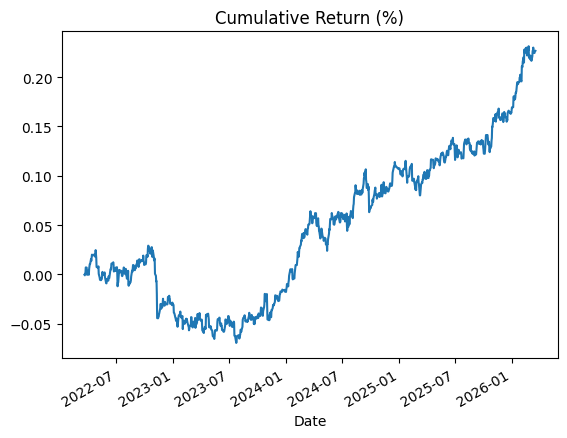

In [110]:

def backtest_momentum(
    price_data: pd.DataFrame,
    vol_eligible: pd.DataFrame,
    mkt_index: str,
    start_date: str = '2026-01-01',
    end_date: str = None,
    rebalance_freq: int = 10,
    lookback: int = 252,
    target_risk: float = 500_000,
    initial_capital: float = 10_000_000,
    exec_bps: float = 2.0,
    financing_annual: float = 0.005,
    **kwargs
):
    all_dates = price_data.index
    start_idx = all_dates.searchsorted(pd.Timestamp(start_date))
    end_idx = len(all_dates) if end_date is None else all_dates.searchsorted(pd.Timestamp(end_date))

    rebal_indices = list(range(start_idx, end_idx, rebalance_freq))

    daily_ret = pd.Series(0.0, index=all_dates[start_idx:end_idx], dtype=float)
    turnovers = []
    prev_positions = pd.Series(dtype=float)
    nav = initial_capital

    for i, reb_idx in enumerate(rebal_indices):
        reb_date = all_dates[reb_idx]

        if i + 1 < len(rebal_indices):
            next_idx = rebal_indices[i + 1]
        else:
            next_idx = end_idx

        try:
            positions, stats = momentum_portfolio(
                price_data, vol_eligible,
                mkt_index=mkt_index,
                lookback=lookback,
                portfolio_start=str(reb_date.date()),
                target_risk=target_risk,
                **kwargs
            )
        except (ValueError, RuntimeError) as e:
            print(f"[{reb_date.date()}] Skipping: {e}")
            continue

        # turnover
        all_tickers = positions.index.union(prev_positions.index)
        old = prev_positions.reindex(all_tickers, fill_value=0)
        new = positions.reindex(all_tickers, fill_value=0)
        turnover = (new - old).abs().sum()
        turnovers.append({
            'date': reb_date, 'turnover': turnover,
            'gross_notional': positions.abs().sum(),
            'n_stocks': len(positions), **stats
        })

        # hold period dollar P&L
        hold_prices = price_data.iloc[reb_idx:next_idx][positions.index]
        entry_prices = hold_prices.iloc[0]
        shares = positions / entry_prices
        hold_pnl = (hold_prices.diff() * shares).sum(axis=1).fillna(0)

        # financing & execution (dollar)
        daily_financing = positions[positions < 0].abs().sum() * financing_annual / 252
        hold_pnl -= daily_financing
        exec_cost = turnover * (exec_bps / 1e4)
        hold_pnl.iloc[0] -= exec_cost

        # convert to percent returns off running NAV
        for dt, dollar_pnl in hold_pnl.items():
            daily_ret.loc[dt] = dollar_pnl / nav
            nav *= (1 + daily_ret.loc[dt])

        # drifted positions
        end_prices = hold_prices.iloc[-1]
        prev_positions = shares * end_prices

    # summary
    cum_ret = (1 + daily_ret).cumprod() - 1
    ann_ret = daily_ret.mean() * 252
    ann_vol = daily_ret.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0

    print(f"Backtest: {daily_ret.index[0].date()} → {daily_ret.index[-1].date()}")
    print(f"Cumulative Return: {cum_ret.iloc[-1]:.2%}")
    print(f"Ann. Return:       {ann_ret:.2%}")
    print(f"Ann. Vol:          {ann_vol:.2%}")
    print(f"Sharpe:            {sharpe:.2f}")
    print(f"Rebalances:        {len(turnovers)}")

    return daily_ret, turnovers

ret, rebs = backtest_momentum(
    prices_df_eu, vol_eligible_eu,
    mkt_index='.STOXX50E',
    start_date='2022-03-20',
    end_date='2026-03-20',
    rebalance_freq=7,
    lookback=252,
    target_risk=500_000,
    initial_capital=10_000_000
)

((1 + ret).cumprod() - 1).plot(title='Cumulative Return (%)')

### Beta Neturalisation

In [112]:
positions = most_recent_positions()
start_date = '2026-03-16'

print('portfolio_beta', portfolio_beta(positions).round(3))
print('enforced SPX hedge', forced_hedge(positions))
print('risk', risk(positions, start_date))
plot_portfolio_returns(positions, start_date=start_date) # stats['entry_date']

FileNotFoundError: [Errno 2] No such file or directory: 'local_data/data/lseg_russell_stoxx_2026_02_17.csv'

### Update Portfolio in QRT 

In [ ]:

df = positions.reset_index().rename(
    columns={'RIC': 'internal_code', 0: 'target_notional'}
).assign(currency='USD')
df.sort_values(by=['target_notional'], ascending=[False], inplace=True)
df
# send_new_portfolio(df)

,id_specific,extra_key,value_ts,strategy,internal_code,ric,ticker,target_notional,currency,target_contracts,ref_price,advisor_name
0,ICL05,ICL05_SLAB.OQ,2026-03-24 13:12,ICL05_AMER,SLAB.OQ,SLAB.OQ,SLAB.OQ,233925.016674,USD,0,0.0,ICL05
1,ICL05,ICL05_PARR.N,2026-03-24 13:12,ICL05_AMER,PARR.N,PARR.N,PARR.N,197094.107721,USD,0,0.0,ICL05
2,ICL05,ICL05_HLF.N,2026-03-24 13:12,ICL05_AMER,HLF.N,HLF.N,HLF.N,164401.282920,USD,0,0.0,ICL05
3,ICL05,ICL05_SPHR.N,2026-03-24 13:12,ICL05_AMER,SPHR.N,SPHR.N,SPHR.N,162279.243267,USD,0,0.0,ICL05
4,ICL05,ICL05_LINC.OQ,2026-03-24 13:12,ICL05_AMER,LINC.OQ,LINC.OQ,LINC.OQ,154535.554253,USD,0,0.0,ICL05
...,...,...,...,...,...,...,...,...,...,...,...,...
78,ICL05,ICL05_PRGO.N,2026-03-24 13:12,ICL05_AMER,PRGO.N,PRGO.N,PRGO.N,-228432.328046,USD,0,0.0,ICL05
79,ICL05,ICL05_OGN.N,2026-03-24 13:12,ICL05_AMER,OGN.N,OGN.N,OGN.N,-246971.291811,USD,0,0.0,ICL05
80,ICL05,ICL05_DEI.N,2026-03-24 13:12,ICL05_AMER,DEI.N,DEI.N,DEI.N,-255633.762923,USD,0,0.0,ICL05
81,ICL05,ICL05_OWL.N,2026-03-24 13:12,ICL05_AMER,OWL.N,OWL.N,OWL.N,-318009.240501,USD,0,0.0,ICL05


Found 0 error(s) while validating target_files/qrt_academy_ICL05_20260324-1312.csv
Found 0 error(s) while validating target_files/qrt_academy_ICL05_20260324-1312.csv
Reading private key from: /Users/dcunning/.ssh/icl05_id_rsa
Connecting to sftp.qrt.cloud:22
Logging in as q8576
Uploading target_files/qrt_academy_ICL05_20260324-1312.csv to incoming/amer/qrt_academy_ICL05_20260324-1312.csv
File 'target_files/qrt_academy_ICL05_20260324-1312.csv' successfully uploaded to AMER.


### Factor Portfolio Optimisation

- combine ind mom, mom, value, portfolio optimisation
- benchmarks = [".SPX", ".STOXX50E"]

## Instructions

### Hedging
To hedge excessive residual beta in your equity portfolio:
1.	Compute the beta of each stock using a 250-day covariance with its benchmark:
$$\text{Beta} = 0.2 + 0.8 \times \frac{\text{Cov}_{250d}(\text{stock}, \text{benchmark})}{\text{Var}_{250d}(\text{benchmark})}$$
2. Hedge the beta exposure by taking a position in the benchmark equal to:
$$\text{Hedge Position} = -\text{Beta}$$
3. Benchmarks:
  - AMER: S&P 500 (SPX)
  - EMEA: Eurostoxx50

This means that if a stock has a beta of 1.2, you would short 1.2 units of the benchmark to neutralize the market exposure.

### Trading Limits
There are some trading limits for single stocks: 
- Max position = 2.5% of the 60 trading days ADV 
- Max traded per day = 2.5% of the 60 trading days ADV 

For single stocks, there is also a max position in term of USD: 
- Max position = 2 M USD 

If the implied trading by targets exceeds the above limits, the position will be kept constant until all limits are not exceeded anymore. 

### Trading Costs
The execution price will be the mid-price at the end of the next minute after we have received your file (without format error) on the ftp. Additional execution costs of 2bps also apply, along with 0.5% (annually) for financing. 

100% of dividends are paid on short positions. 70% of dividends are received on long positions. 

### Ex-Ante Portfolio Risk

Risk Formula
$$
\text{Risk}_t = \sqrt{ x_t^\top \, \Sigma_t \, x_t }
$$

Where:
- $x_t$ = portfolio weights at time $t$
- $\Sigma_t$ = covariance matrix of asset returns  

Computation Steps
1. Select last 60 daily returns.  
2. Compute daily P&L:

$$
\text{PnL}_t = \text{positions}_{t-1} \cdot \text{return}_t
$$

3. Compute standard deviation of P&L.  
4. Annualise: multiply by $\sqrt{252}$.  

Simulation Parameters
- Asset class: Equities  
- Regions: AMER, EMEA  
- Universe: Russell 3000, Stoxx 600  
- Trading hours: Standard per region  
- Execution cost: 2 bps  
- Financing cost: 0.5% GMV  
- Dividend tax: 30%  
- Spread cost: 0  
- Max traded/day: 2.5% ADV  
- Position limit: 2.5% ADV  
- Auto-hedging: TRUE  
- Risk limit: 500k USD (annualised)